# 03. Approccio Deep Learning: Rete Neurale Convoluzionale (CNN) in PyTorch
Questo notebook descrive l'implementazione del secondo approccio basato sul Deep Learning. Il processo prevede:
1. Creazione di un PyTorch Custom Dataset e DataLoaders per lo split di Train, Validation e Test.
2. Applicazione di Data Augmentation (rotazione e flip orizzontale) per il set di training per contrastare l'overfitting.
3. Definizione di un'architettura CNN profonda e performante (blocchi convoluzionali con Batch Normalization, Max Pooling, Dropout e livelli Fully Connected).
4. Definizione del ciclo di addestramento ottimizzato per l'hardware Apple Silicon (MPS - Metal Performance Shaders) o GPU CUDA.
5. Valutazione e salvataggio del modello.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

sns.set_theme(style="white")
plt.rcParams["figure.figsize"] = (8, 6)

In [2]:
# Configurazione del dispositivo per l'accelerazione hardware
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(f"Dispositivo di calcolo selezionato: {device}")

Dispositivo di calcolo selezionato: mps


In [3]:
# Carichiamo il dataset pre-salvato
data_path = "../data/fer2013.npz"
if not os.path.exists(data_path):
    data_path = "data/fer2013.npz"

data = np.load(data_path)
X_train, y_train = data["train_images"], data["train_labels"]
X_val, y_val = data["val_images"], data["val_labels"]
X_test, y_test = data["test_images"], data["test_labels"]

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

Train: (25117, 48, 48), Val: (5380, 48, 48), Test: (5390, 48, 48)


## Definizione del Dataset e Data Augmentation
Definiamo una classe custom `FERDataset` che converte gli array numpy in immagini PIL al volo per consentire l'uso delle funzioni di Data Augmentation offerte da `torchvision.transforms` (flip orizzontali, rotazioni casuali).

In [4]:
class FERDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform
        
    def __len__(self):
        return len(self.images)
        
    def __getitem__(self, idx):
        img = Image.fromarray(self.images[idx])
        label = self.labels[idx]
        
        if self.transform:
            img = self.transform(img)
            
        return img, label

# Definiamo le trasformazioni
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

val_test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Creazione dei dataset
train_dataset = FERDataset(X_train, y_train, transform=train_transform)
val_dataset = FERDataset(X_val, y_val, transform=val_test_transform)
test_dataset = FERDataset(X_test, y_test, transform=val_test_transform)

# Creazione dei dataloader
BATCH_SIZE = 128
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("Dataloaders pronti.")

Dataloaders pronti.


## Architettura della CNN
Definiamo un'architettura convoluzionale con 3 macro-blocchi (ciascuno formato da due convoluzioni a filtro $3\times3$, Batch Normalization, Max Pooling per ridurre le dimensioni e Dropout per regolarizzare) e 2 strati Fully Connected finali.

In [5]:
class EmotionCNN(nn.Module):
    def __init__(self):
        super(EmotionCNN, self).__init__()
        
        # Blocco 1: Input 48x48x1 -> Conv 64 -> MaxPool -> 24x24x64
        self.conv1 = nn.Conv2d(1, 64, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(64)
        self.conv2 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool1 = nn.MaxPool2d(2, 2)
        self.drop1 = nn.Dropout(0.25)
        
        # Blocco 2: Input 24x24x64 -> Conv 128 -> MaxPool -> 12x12x128
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.conv4 = nn.Conv2d(128, 128, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(128)
        self.pool2 = nn.MaxPool2d(2, 2)
        self.drop2 = nn.Dropout(0.25)
        
        # Blocco 3: Input 12x12x128 -> Conv 256 -> MaxPool -> 6x6x256
        self.conv5 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn5 = nn.BatchNorm2d(256)
        self.conv6 = nn.Conv2d(256, 256, kernel_size=3, padding=1)
        self.bn6 = nn.BatchNorm2d(256)
        self.pool3 = nn.MaxPool2d(2, 2)
        self.drop3 = nn.Dropout(0.25)
        
        # Fully Connected: Input 256 * 6 * 6 = 9216 -> Dense 512 -> Dense 7
        self.fc1 = nn.Linear(256 * 6 * 6, 512)
        self.bn_fc1 = nn.BatchNorm1d(512)
        self.drop_fc1 = nn.Dropout(0.5)
        self.fc2 = nn.Linear(512, 7)
        
    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.pool1(x)
        x = self.drop1(x)
        
        x = F.relu(self.bn3(self.conv3(x)))
        x = F.relu(self.bn4(self.conv4(x)))
        x = self.pool2(x)
        x = self.drop2(x)
        
        x = F.relu(self.bn5(self.conv5(x)))
        x = F.relu(self.bn6(self.conv6(x)))
        x = self.pool3(x)
        x = self.drop3(x)
        
        # Flattening
        x = x.view(-1, 256 * 6 * 6)
        
        x = F.relu(self.bn_fc1(self.fc1(x)))
        x = self.drop_fc1(x)
        x = self.fc2(x)
        return x

model = EmotionCNN().to(device)
print(model)

EmotionCNN(
  (conv1): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (drop1): Dropout(p=0.25, inplace=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (conv4): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (drop2): Dropout(p=0.25, inplace=False)
  (conv5): Conv2d(12

## Addestramento del Modello
Definiamo i parametri di addestramento:
- **Loss**: CrossEntropyLoss.
- **Optimizer**: Adam con learning rate iniziale pari a `0.001` e regolarizzazione $L_2$ (`weight_decay=1e-4`).
- **Scheduler**: `ReduceLROnPlateau` che dimezza il learning rate se l'accuratezza sul validation set non migliora per 3 epoche.
Addestreremo per **30 epoche**, salvando costantemente i pesi del modello che ottiene la miglior accuratezza di validazione.

In [6]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)

EPOCHS = 30
best_val_acc = 0.0
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

os.makedirs("../models", exist_ok=True)
os.makedirs("models", exist_ok=True)
models_dir = "../models" if os.path.exists("../models") else "models"
best_model_path = os.path.join(models_dir, "cnn_model.pth")

for epoch in range(EPOCHS):
    # Training Phase
    model.train()
    train_loss, train_correct, train_total = 0.0, 0, 0
    
    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        train_total += targets.size(0)
        train_correct += predicted.eq(targets).sum().item()
        
    train_epoch_loss = train_loss / train_total
    train_epoch_acc = train_correct / train_total
    
    # Validation Phase
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    
    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            
            val_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            val_total += targets.size(0)
            val_correct += predicted.eq(targets).sum().item()
            
    val_epoch_loss = val_loss / val_total
    val_epoch_acc = val_correct / val_total
    
    # Aggiorna lo scheduler
    scheduler.step(val_epoch_acc)
    
    # Salva nello storico
    history["train_loss"].append(train_epoch_loss)
    history["train_acc"].append(train_epoch_acc)
    history["val_loss"].append(val_epoch_loss)
    history["val_acc"].append(val_epoch_acc)
    
    print(f"Epoca [{epoch+1:02d}/{EPOCHS}]: "
          f"Train Loss: {train_epoch_loss:.4f} | Train Acc: {train_epoch_acc:.4f} || "
          f"Val Loss: {val_epoch_loss:.4f} | Val Acc: {val_epoch_acc:.4f}")
          
    # Salvataggio del modello migliore
    if val_epoch_acc > best_val_acc:
        best_val_acc = val_epoch_acc
        torch.save(model.state_dict(), best_model_path)
        print(f"  --> Nuovo miglior modello salvato con accuratezza validazione: {best_val_acc:.4f}")

print("Training completato!")

Epoca [01/30]: Train Loss: 1.5766 | Train Acc: 0.3852 || Val Loss: 1.3355 | Val Acc: 0.4868
  --> Nuovo miglior modello salvato con accuratezza validazione: 0.4868


Epoca [02/30]: Train Loss: 1.3092 | Train Acc: 0.4961 || Val Loss: 1.2242 | Val Acc: 0.5279
  --> Nuovo miglior modello salvato con accuratezza validazione: 0.5279


Epoca [03/30]: Train Loss: 1.2230 | Train Acc: 0.5312 || Val Loss: 1.2180 | Val Acc: 0.5400
  --> Nuovo miglior modello salvato con accuratezza validazione: 0.5400


Epoca [04/30]: Train Loss: 1.1823 | Train Acc: 0.5493 || Val Loss: 1.1267 | Val Acc: 0.5708
  --> Nuovo miglior modello salvato con accuratezza validazione: 0.5708


Epoca [05/30]: Train Loss: 1.1325 | Train Acc: 0.5684 || Val Loss: 1.1346 | Val Acc: 0.5794
  --> Nuovo miglior modello salvato con accuratezza validazione: 0.5794


...

Epoca [26/30]: Train Loss: 0.7701 | Train Acc: 0.7108 || Val Loss: 0.9351 | Val Acc: 0.6678
  --> Nuovo miglior modello salvato con accuratezza validazione: 0.6678


Epoca [27/30]: Train Loss: 0.7530 | Train Acc: 0.7195 || Val Loss: 0.9338 | Val Acc: 0.6697
  --> Nuovo miglior modello salvato con accuratezza validazione: 0.6697


Epoca [28/30]: Train Loss: 0.7394 | Train Acc: 0.7223 || Val Loss: 0.9365 | Val Acc: 0.6706
  --> Nuovo miglior modello salvato con accuratezza validazione: 0.6706


Epoca [29/30]: Train Loss: 0.7223 | Train Acc: 0.7291 || Val Loss: 0.9348 | Val Acc: 0.6662


Epoca [30/30]: Train Loss: 0.7116 | Train Acc: 0.7358 || Val Loss: 0.9398 | Val Acc: 0.6675
Training completato!


## Grafici delle Curve di Apprendimento
Visualizziamo l'andamento della Loss e dell'Accuratezza durante l'addestramento.

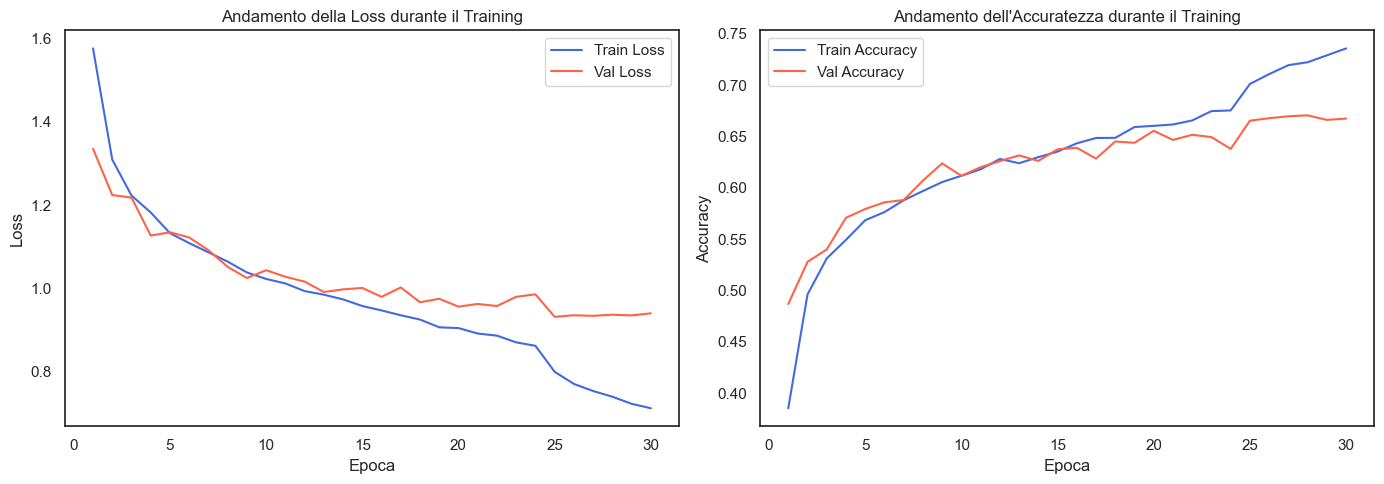

In [7]:
plt.figure(figsize=(14, 5))

# Grafico della Loss
plt.subplot(1, 2, 1)
plt.plot(range(1, EPOCHS + 1), history["train_loss"], label="Train Loss", color="royalblue")
plt.plot(range(1, EPOCHS + 1), history["val_loss"], label="Val Loss", color="tomato")
plt.title("Andamento della Loss durante il Training")
plt.xlabel("Epoca")
plt.ylabel("Loss")
plt.legend()

# Grafico dell'Accuratezza
plt.subplot(1, 2, 2)
plt.plot(range(1, EPOCHS + 1), history["train_acc"], label="Train Accuracy", color="royalblue")
plt.plot(range(1, EPOCHS + 1), history["val_acc"], label="Val Accuracy", color="tomato")
plt.title("Andamento dell'Accuratezza durante il Training")
plt.xlabel("Epoca")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

## Valutazione sul Test Set
Carichiamo i migliori pesi salvati ed eseguiamo la valutazione finale sul Test Set (PrivateTest).

In [8]:
# Carichiamo il modello migliore salvato
model.load_state_dict(torch.load(best_model_path, map_location=device))
model.eval()

test_preds = []
test_targets = []

with torch.no_grad():
    for inputs, targets in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, predicted = outputs.max(1)
        test_preds.extend(predicted.cpu().numpy())
        test_targets.extend(targets.numpy())

test_acc = accuracy_score(test_targets, test_preds)
print(f"Accuratezza complessiva della CNN sul Test Set: {test_acc:.4f}\n")

EMOTIONS = {
    0: "Rabbia (Angry)",
    1: "Disgusto (Disgust)",
    2: "Paura (Fear)",
    3: "Felicità (Happy)",
    4: "Tristezza (Sad)",
    5: "Sorpresa (Surprise)",
    6: "Neutro (Neutral)"
}
target_names = [EMOTIONS[i] for i in range(7)]

print("Report di classificazione:")
print(classification_report(test_targets, test_preds, target_names=target_names))

Accuratezza complessiva della CNN sul Test Set: 0.6614

Report di classificazione:
                     precision    recall  f1-score   support

     Rabbia (Angry)       0.61      0.52      0.56       744
 Disgusto (Disgust)       0.88      0.43      0.58        83
       Paura (Fear)       0.51      0.50      0.50       769
   Felicità (Happy)       0.83      0.90      0.86      1349
    Tristezza (Sad)       0.54      0.52      0.53       913
Sorpresa (Surprise)       0.77      0.75      0.76       601
   Neutro (Neutral)       0.60      0.67      0.63       931

           accuracy                           0.66      5390
          macro avg       0.68      0.61      0.63      5390
       weighted avg       0.66      0.66      0.66      5390



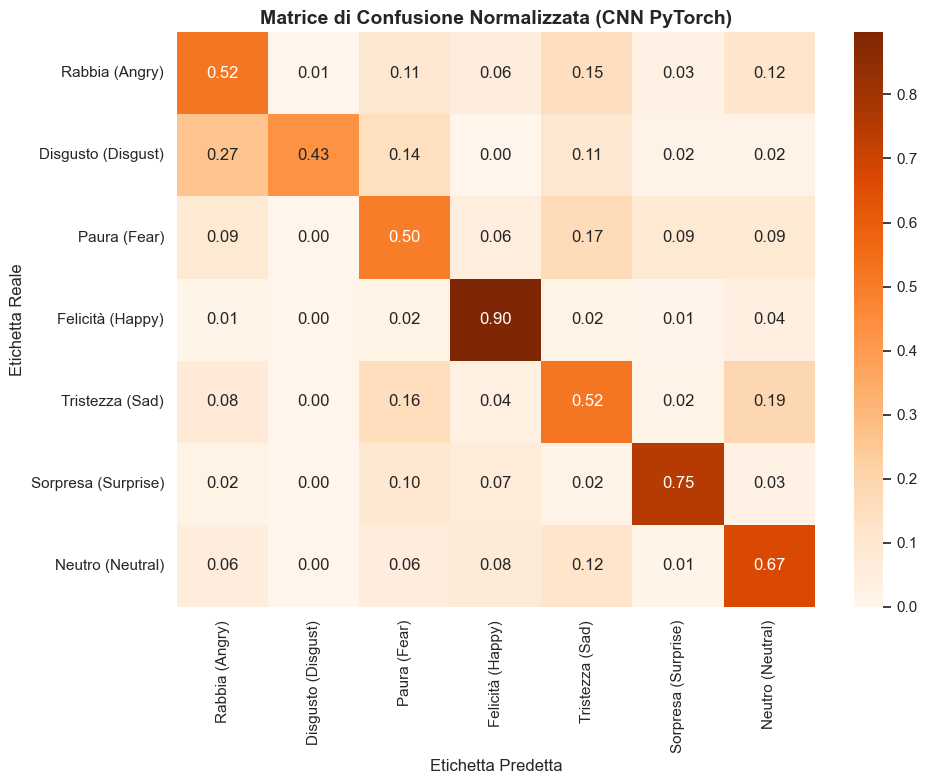

In [9]:
cm = confusion_matrix(test_targets, test_preds)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_normalized, 
    annot=True, 
    fmt=".2f", 
    cmap="Oranges", 
    xticklabels=target_names, 
    yticklabels=target_names
)
plt.title("Matrice di Confusione Normalizzata (CNN PyTorch)", fontsize=14, fontweight='bold')
plt.ylabel("Etichetta Reale", fontsize=12)
plt.xlabel("Etichetta Predetta", fontsize=12)
plt.tight_layout()
plt.show()